# **Проект по компьютерному зрению**

In [51]:
! pip install -r requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
# import kagglehub
# 
# # kaggle_api = KGAT_8eb0727ee6d566add6db98054cc75b1f
# kagglehub.login()

In [53]:
# kagglehub.competition_download(
#     "ml-intensive-yandex-academy-spring-2026",
#     output_dir="./data"
# )

In [54]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import transforms 
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [55]:
def dir_length(
        path: str
) -> int:
    abs_path = os.path.abspath(path)
    return len(os.listdir(abs_path))

In [56]:
class CustomDataset(Dataset):
    def __init__(
            self,
            img_dir: str,
            _train: bool = True,
            csv_path: str = None,
            _transform: transforms.Compose = None
    ):
        self.img_dir = img_dir
        self.train = _train
        self.data = pd.read_csv(
            csv_path, names=["id", "label"]
        ) if _train else None
        self._transform = _transform
    
    def __len__(self):
        return dir_length(self.img_dir)
    
    def __getitem__(
            self,
            idx: int
    ):
        if self.train:
            label = torch.tensor(
                self.data.iloc[idx]["label"],
                dtype=torch.float32
            )  
        else:
            label = idx
            
        path = os.path.join(self.img_dir, f"{idx}.jpg")
        img = Image.open(path).convert("RGB")
        if self._transform:
            img = self._transform(img)
            
        return img, label

In [57]:
IMAGE_SIZE = (256, 256)  # Для последней версии


transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    # Сюда добавить аугментации
    transforms.ToTensor()
])

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

dataset = CustomDataset(
    img_dir="./data/dataset/train_images",
    csv_path="./data/dataset/train_solution.csv",
    _train=True,
    _transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

BATCH_SIZE = 128

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

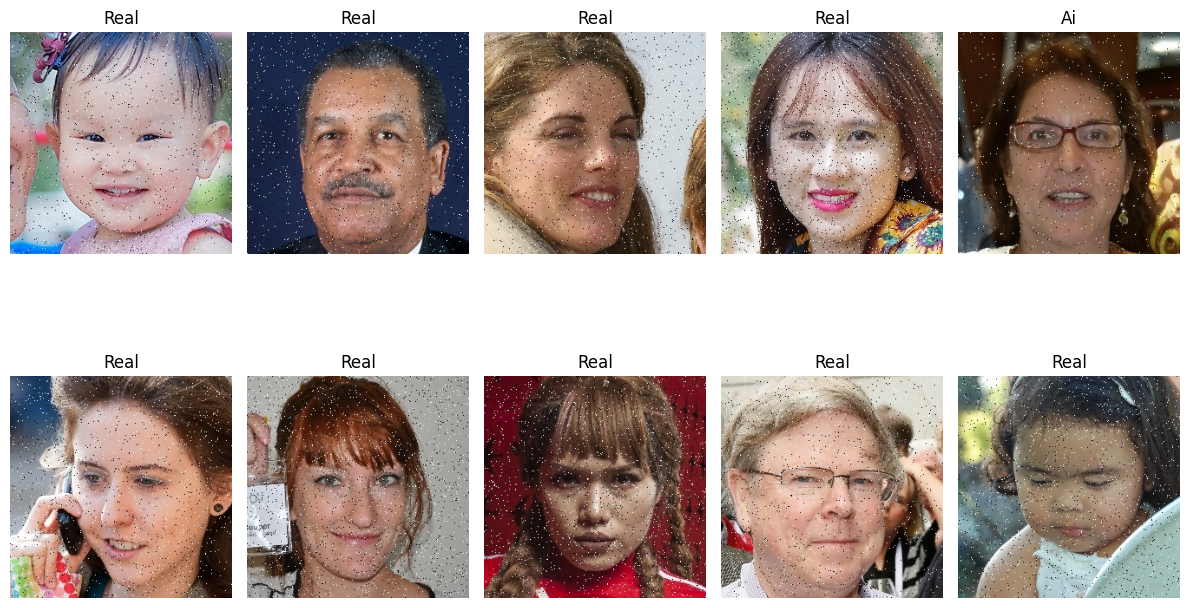

In [58]:
to_pil = transforms.ToPILImage()


def imshow(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")

dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    imshow(images[i])
    plt.title("Real" if labels[i].item() == 0 else "Ai")
plt.tight_layout()
plt.show()

In [59]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def show_summary(self):
        summary(self, input_size=(3, 128, 128))
        return

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x



class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 1)
            # нет сигмоид, так что надо использовать bcewithlogitsloss
        )

    def show_summary(self):
        summary(self, input_size=(3, 256, 256))
        return

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)
        x = self.fc(x)
        return x


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        return nn.functional.relu(self.conv(x) + self.shortcut(x))


class ModelV3_Improved(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            ResBlock(3, 32, stride=2),
            ResBlock(32, 64, stride=2),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 256, stride=2),
            nn.Dropout2d(0.3)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def show_summary(self):
        summary(self, input_size=(3, 256, 256))
        return

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class ModelV4(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def show_summary(self):
        summary(self, input_size=(3, 256, 256))
        return

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [60]:
LEARNING_RATE = 0.01
criterion = nn.BCEWithLogitsLoss()

In [61]:
modelV3 = ModelV3().to(device)
optimizerV3 = optim.Adam(
    modelV3.parameters(),
    lr=LEARNING_RATE
)
modelV3

ModelV3(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [62]:
modelV3.show_summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
       BatchNorm2d-5           [-1, 64, 64, 64]             128
              ReLU-6           [-1, 64, 64, 64]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
       BatchNorm2d-8          [-1, 128, 32, 32]             256
              ReLU-9          [-1, 128, 32, 32]               0
           Conv2d-10          [-1, 128, 16, 16]         147,584
      BatchNorm2d-11          [-1, 128, 16, 16]             256
             ReLU-12          [-1, 128, 16, 16]               0
AdaptiveAvgPool2d-13            [-1, 128, 1, 1]               0
          Flatten-14                  [

In [63]:
modelV4 = ModelV4().to(device)
optimizerV4 = optim.Adam(
    modelV4.parameters(),
    lr=LEARNING_RATE
)
modelV4

ModelV4(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [64]:
modelV4.show_summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]             448
       BatchNorm2d-2         [-1, 16, 128, 128]              32
              ReLU-3         [-1, 16, 128, 128]               0
            Conv2d-4           [-1, 32, 64, 64]           4,640
       BatchNorm2d-5           [-1, 32, 64, 64]              64
              ReLU-6           [-1, 32, 64, 64]               0
            Conv2d-7           [-1, 64, 32, 32]          18,496
       BatchNorm2d-8           [-1, 64, 32, 32]             128
              ReLU-9           [-1, 64, 32, 32]               0
           Conv2d-10          [-1, 128, 16, 16]          73,856
      BatchNorm2d-11          [-1, 128, 16, 16]             256
             ReLU-12          [-1, 128, 16, 16]               0
          Flatten-13                [-1, 32768]               0
           Linear-14                  [

In [65]:
def show_losses(
        train_loss_hist,
        train_accs_hist,
        val_loss_hist,
        val_accs_hist
):
    clear_output()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_hist, label="Train loss")
    plt.plot(val_loss_hist, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss curves")

    plt.subplot(1, 2, 2)
    plt.plot(train_accs_hist, label="Train acc")
    plt.plot(val_accs_hist, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy curves")

    plt.tight_layout()
    plt.show()

In [66]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    for img, labels in loader:
        img, labels = img.to(device), labels.to(device).unsqueeze(1)
        outputs = model(img)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        probs = torch.sigmoid(outputs)
        
        preds = (probs > 0.5).int()
        correct += (preds == labels).sum().item()
        
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


@torch.inference_mode()  # аналог no_grad()
def evaluate(model, loader, optimizer):
    model.eval()
    total_loss = 0
    correct = 0
    
    for img, labels in loader:
        img, labels = img.to(device), labels.to(device).unsqueeze(1)
        outputs = model(img)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item()
        probs = torch.sigmoid(outputs)
        
        preds = (probs > 0.5).int()
        correct += (preds == labels).sum().item()
        
    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    
    return avg_loss, accuracy

In [67]:
def train(
        model,
        _train_loader,
        _val_loader,
        optimizer,
        epochs: int = 10
):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model,
            _train_loader,
            optimizer
        )
        val_loss, val_acc = evaluate(
            model,
            _val_loader,
            optimizer
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        show_losses(
            train_loss_hist=train_losses,
            train_accs_hist=train_accs,
            val_loss_hist=val_losses,
            val_accs_hist=val_accs
        )
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs
    }

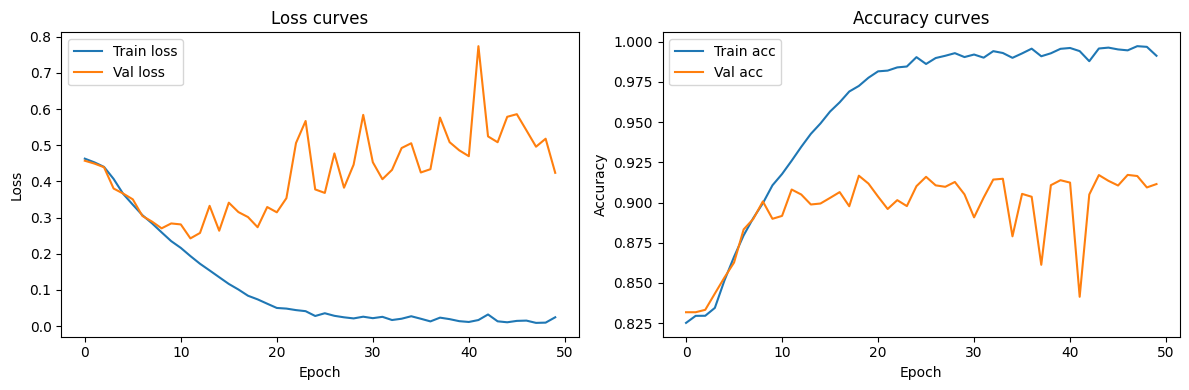

Epoch 50/50 | Train Loss: 0.0246 | Train Acc: 0.9913 | Val Loss: 0.4238 | Val Acc: 0.9115


In [68]:
history_data_V3 = train(
    model=modelV3,
    _train_loader=train_loader,
    _val_loader=val_loader,
    optimizer=optimizerV3,
    epochs=50
)

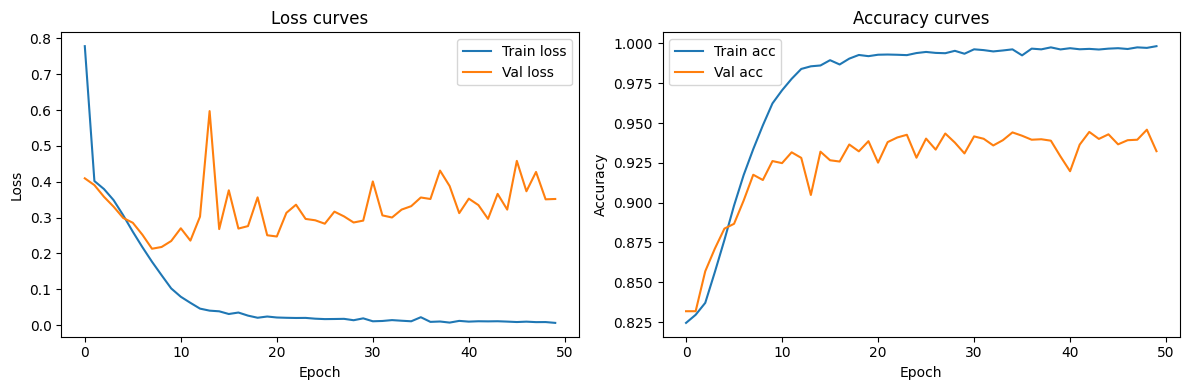

Epoch 50/50 | Train Loss: 0.0063 | Train Acc: 0.9982 | Val Loss: 0.3521 | Val Acc: 0.9323


In [69]:
history_data_V4 = train(
    model=modelV4,
    _train_loader=train_loader,
    _val_loader=val_loader,
    optimizer=optimizerV4,
    epochs=50
)

In [70]:
test_dataset = CustomDataset(
    img_dir="./data/dataset/test_images",
    _train=False,
    _transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [71]:
def predict(model, test_loader):
    model.eval()

    predictions = []

    with torch.no_grad():
        for images, img_ids in test_loader:
            images = images.to(device)

            outputs = model(images)
            probs = outputs.squeeze()

            preds = (probs > 0.5).int().cpu().numpy()        
            for img_id, pred in zip(img_ids, preds):
                predictions.append((img_id.item(), pred))

    return predictions

In [72]:
preds = predict(modelV3, test_loader)
df = pd.DataFrame(preds, columns=["id", "label"])
df = df.sort_values("id")
df

,id,label
0,0,0
1,1,1
2,2,0
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0
